# Notebook 07 — Final Evaluation, Interpretation, and Operational Impact

**CIND820 Capstone — Milestone 4** | Mubarak Ahmed (501345730)

This notebook completes the analysis. It touches the held-out test set for the first and only time in Milestone 4, then closes each research question:

1. **Final test evaluation** of the deterministic final champion and baseline fitted in Notebook 06 (effectiveness), with efficiency measurements (time, compute, artifact size).
2. **SHAP attribution** aggregated to the shipment-attribute level (RQ1).
3. **Cost-sensitive decision analysis** targeting the At-risk weakness identified in Milestone 3 — decision weights selected on out-of-fold training predictions only, applied once to the test set.
4. **Dynamic safety-stock simulation** implementing the Milestone 1 formula `SS = z × σ(predicted lead-time deviation) × average daily demand` and comparing it against the fixed-buffer policy (RQ3).

Inputs: model artifacts from Notebook 06, feature matrices from Notebook 03, split frames from Notebook 02.

In [ ]:
import json
import os
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             f1_score)
from sklearn.preprocessing import label_binarize

sys.path.insert(0, "../src")
import impact
from final_models import _make_xgb

RANDOM_STATE = 42
CLASSES = [0, 1, 2]
CLASS_NAMES = ["On-time (0)", "At-risk (1)", "Delayed (2)"]
plt.rcParams["figure.dpi"] = 110

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
X_train = pd.read_parquet("../data/processed/X_train.parquet")
y_train = X_train.pop("delay_class")
X_test = pd.read_parquet("../data/processed/X_test.parquet")
y_test = X_test.pop("delay_class")
train_df = pd.read_parquet("../data/processed/train.parquet")
test_df = pd.read_parquet("../data/processed/test.parquet")

champion = joblib.load("../outputs/models/xgboost_champion_final.joblib")
baseline = joblib.load("../outputs/models/logreg_baseline_final.joblib")
with open("../outputs/models/final_champion_meta.json") as f:
    champ_meta = json.load(f)
final_params = champ_meta["final_params"]
print("Final champion:", champ_meta["champion_label"],
      "| selection basis:", champ_meta["selection_basis"])
print("Configuration:", final_params)
print(f"Test set: {X_test.shape[0]} rows x {X_test.shape[1]} features")

Final champion: XGBoost (M3 default) | selection basis: higher repeated-CV mean macro-F1
Configuration: {'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 6}
Test set: 2065 rows x 154 features


## 1. Final test evaluation (effectiveness)

Both final models are evaluated once against the 2,065-row held-out test set. The comparison reference is the repeated-CV mean from Notebook 06, giving the final generalization check.

In [ ]:
y_bin = label_binarize(y_test, classes=CLASSES)
rows, probas = [], {}
for name, model in [("XGBoost (final champion)", champion),
                    ("LogisticRegression (baseline)", baseline)]:
    t0 = time.perf_counter()
    proba = model.predict_proba(X_test)
    pred_time = time.perf_counter() - t0
    probas[name] = proba
    pred = np.argmax(proba, axis=1)
    ap_per_class = average_precision_score(y_bin, proba, average=None)
    rows.append({
        "model": name,
        "test_macro_f1": round(f1_score(y_test, pred, average="macro"), 4),
        "test_auprc_macro": round(float(np.mean(ap_per_class)), 4),
        "test_auprc_delayed": round(float(ap_per_class[2]), 4),
        "pred_time_s_full_test": round(pred_time, 4),
    })
rcv = pd.read_csv("../outputs/tables/repeated_cv_summary.csv")
label_map = {champ_meta["champion_label"]: "XGBoost (final champion)",
             "LogisticRegression (baseline)":
                 "LogisticRegression (baseline)"}
rcv["model"] = rcv["model"].map(label_map)
test_metrics = pd.DataFrame(rows).merge(
    rcv.dropna(subset=["model"])[["model", "macro_f1_mean"]].rename(
        columns={"macro_f1_mean": "repeated_cv_macro_f1_mean"}),
    on="model", how="left")
test_metrics["generalization_gap"] = (
    test_metrics["test_macro_f1"]
    - test_metrics["repeated_cv_macro_f1_mean"]).round(4)
test_metrics.to_csv("../outputs/tables/test_metrics_final.csv", index=False)
test_metrics

,model,test_macro_f1,test_auprc_macro,test_auprc_delayed,pred_time_s_full_test,repeated_cv_macro_f1_mean,generalization_gap
0,XGBoost (final champion),0.6135,0.5967,0.5047,0.0694,0.5923,0.0212
1,LogisticRegression (baseline),0.3779,0.4388,0.2071,0.0069,0.3713,0.0066


In [ ]:
proba_champ = probas["XGBoost (final champion)"]
pred_champ = np.argmax(proba_champ, axis=1)
report = impact.per_class_report(y_test, pred_champ)
report.to_csv("../outputs/tables/test_classification_report_final.csv",
              index=False)
report

,class,precision,recall,f1,support
0,On-time (0),0.938,0.920,0.929,1828
1,At-risk (1),0.339,0.413,0.373,138
2,Delayed (2),0.524,0.556,0.539,99
3,Macro average,0.600,0.629,0.613,2065


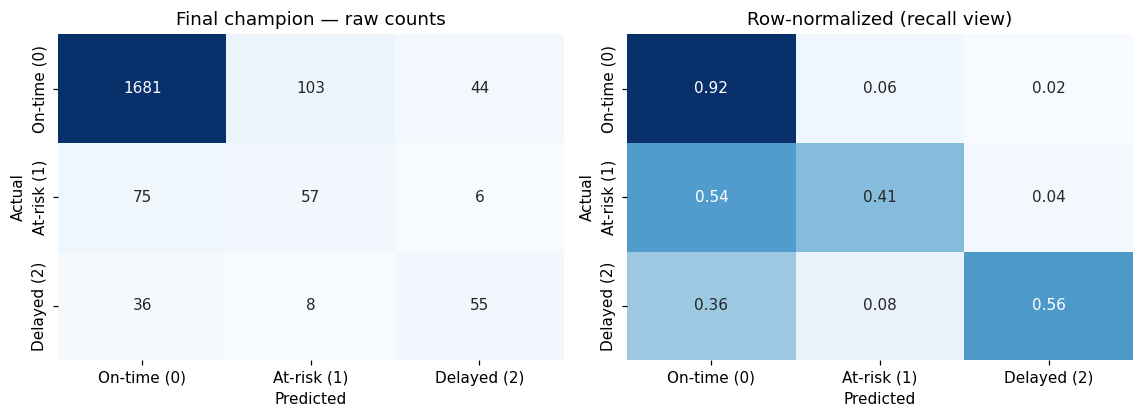

In [ ]:
cm = confusion_matrix(y_test, pred_champ)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.9))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Final champion — raw counts")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Row-normalized (recall view)")
for ax in axes:
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix_final.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 2. Efficiency

Time and compute cost of the final pipeline, measured on a single CPU thread (the deterministic configuration). The one-off tuning cost is reported separately from the recurring cost of refitting and scoring, because a planner deploying this system pays the tuning cost once but the refit cost at every retraining cycle.

In [ ]:
size_champ = os.path.getsize(
    "../outputs/models/xgboost_champion_final.joblib") / 1e6
size_base = os.path.getsize(
    "../outputs/models/logreg_baseline_final.joblib") / 1e6
per_shipment_ms = (test_metrics.loc[0, "pred_time_s_full_test"]
                   / len(X_test) * 1000)
efficiency = pd.DataFrame([
    {"measure": "One-off hyperparameter search (20 configs x 5 folds)",
     "value": f"{champ_meta['tuning_wall_clock_minutes']} min"},
    {"measure": "Final champion fit (full training split, single thread)",
     "value": f"{champ_meta['fit_times']['champion_fit_time_s']} s"},
    {"measure": "Final baseline fit",
     "value": f"{champ_meta['fit_times']['baseline_fit_time_s']} s"},
    {"measure": "Champion scoring, full 2,065-row test set",
     "value": f"{test_metrics.loc[0, 'pred_time_s_full_test']} s"},
    {"measure": "Champion scoring per shipment",
     "value": f"{per_shipment_ms:.3f} ms"},
    {"measure": "Champion artifact size",
     "value": f"{size_champ:.2f} MB"},
    {"measure": "Baseline artifact size",
     "value": f"{size_base:.2f} MB"},
])
efficiency.to_csv("../outputs/tables/efficiency_summary.csv", index=False)
efficiency

,measure,value
0,One-off hyperparameter search (20 configs x 5 ...,8.1 min
1,"Final champion fit (full training split, singl...",4.25 s
2,Final baseline fit,0.47 s
3,"Champion scoring, full 2,065-row test set",0.0694 s
4,Champion scoring per shipment,0.034 ms
5,Champion artifact size,3.62 MB
6,Baseline artifact size,0.01 MB


## 3. SHAP attribution at the attribute level (RQ1)

TreeExplainer SHAP values are computed on the full test set, then aggregated from 154 model columns back to the original shipment attributes (all one-hot vendor columns sum to "Vendor", and so on). This answers RQ1 at the level a procurement planner controls: mode, vendor, route, commodity — not individual dummy columns.

In [ ]:
explainer = shap.TreeExplainer(champion)
sv = explainer.shap_values(X_test)
sv = np.asarray(sv)
if sv.ndim == 3 and sv.shape[0] == len(CLASSES):   # (classes, n, feat)
    sv = np.transpose(sv, (1, 2, 0))                # -> (n, feat, classes)
print("SHAP value tensor:", sv.shape)
grouped = impact.grouped_shap_importance(sv, list(X_test.columns))
grouped.round(4).to_csv("../outputs/tables/shap_grouped_importance.csv",
                        index=False)
grouped.round(4)

SHAP value tensor: (2065, 154, 3)


,attribute,class_0,class_1,class_2,overall
0,Country,0.6103,0.4665,0.9240,0.6669
1,Vendor,0.8856,0.6667,0.2725,0.6083
2,Freight Cost (log),0.3645,0.4673,0.6195,0.4838
3,Weight (log),0.3239,0.3370,0.6230,0.4280
4,Line Item Quantity,0.2440,0.3061,0.4916,0.3472
5,Line Item Value (log),0.3051,0.2832,0.3954,0.3279
6,Dosage Form,0.1569,0.2539,0.1822,0.1977
7,Shipment Mode,0.3363,0.1129,0.1317,0.1936
8,Sub Classification,0.0556,0.0236,0.0483,0.0425
9,Freight Cost Imputed Flag,0.0278,0.0320,0.0471,0.0357


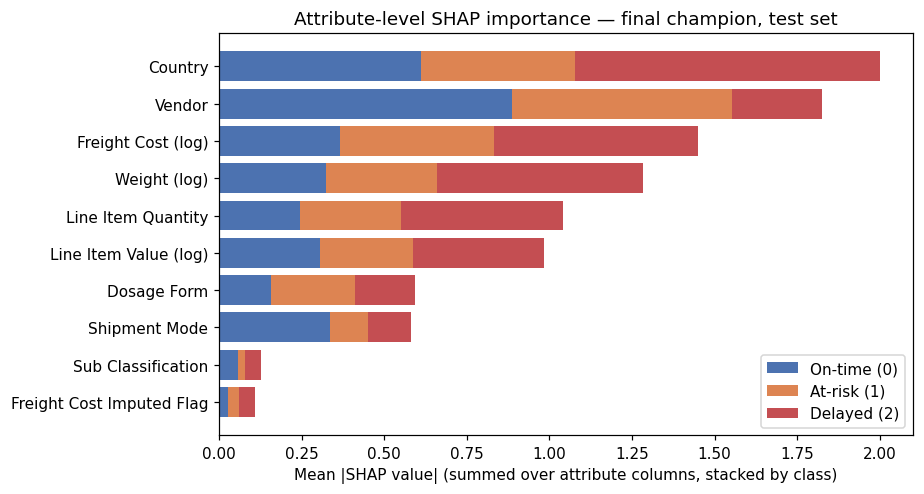

In [ ]:
top = grouped.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
bars = np.zeros(len(top))
colors = ["#4C72B0", "#DD8452", "#C44E52"]
for c, (col, label) in enumerate(zip(["class_0", "class_1", "class_2"],
                                     CLASS_NAMES)):
    ax.barh(top["attribute"], top[col], left=bars,
            color=colors[c], label=label)
    bars += top[col].to_numpy()
ax.set_xlabel("Mean |SHAP value| (summed over attribute columns, "
              "stacked by class)")
ax.set_title("Attribute-level SHAP importance — final champion, test set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/figures/shap_grouped_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

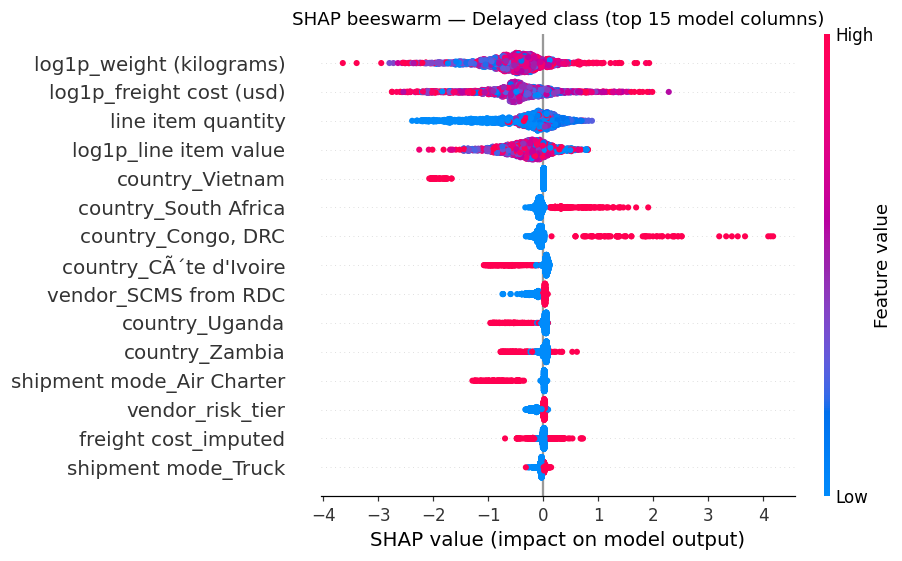

In [ ]:
# Detail view: which individual columns drive the Delayed class.
plt.figure(figsize=(8.5, 5.2))
shap.summary_plot(sv[:, :, 2], X_test, max_display=15, show=False,
                  plot_size=None)
plt.title("SHAP beeswarm — Delayed class (top 15 model columns)")
plt.tight_layout()
plt.savefig("../outputs/figures/shap_beeswarm_delayed.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 4. Cost-sensitive decision analysis

Milestone 3 identified At-risk recall (0.333) as the champion's central weakness, and noted that a missed at-risk shipment is operationally costlier than a false alarm: the At-risk window is precisely where a planner can still intervene. The default argmax rule ignores this asymmetry.

An illustrative cost matrix encodes the asymmetry (missed At-risk warning = 5× a false alarm; missed severe delay = 10×; full matrix in `src/impact.py`). Class-probability weight multipliers are selected to minimize expected cost on **out-of-fold training predictions only** — the same leakage discipline as every other selection step in this project — and the chosen rule is then applied once to the test set.

In [ ]:
make_champ = lambda: _make_xgb(final_params, early_stopping=False)
t0 = time.perf_counter()
proba_oof = impact.oof_probabilities(X_train, y_train, make_champ)
print(f"OOF probabilities computed in {time.perf_counter()-t0:.0f} s "
      "(5 single-threaded champion fits)")
weight_grid = impact.tune_decision_weights(proba_oof, y_train.to_numpy())
weight_grid.round(4).to_csv("../outputs/tables/decision_weight_grid.csv",
                            index=False)
weight_grid.head(8).round(4)

OOF probabilities computed in 18 s (5 single-threaded champion fits)


,w_on_time,w_at_risk,w_delayed,oof_expected_cost,oof_macro_f1,oof_recall_at_risk,oof_recall_delayed
0,1.0,2.5,3.0,0.4267,0.5455,0.5190,0.5530
1,1.0,2.0,4.0,0.4272,0.5400,0.4792,0.5758
2,1.0,2.0,3.0,0.4274,0.5488,0.4846,0.5556
3,1.0,2.5,4.0,0.4275,0.5351,0.5118,0.5682
4,1.0,2.5,2.5,0.4323,0.5498,0.5226,0.5278
5,1.0,2.0,2.5,0.4326,0.5529,0.4846,0.5328
6,1.0,3.0,3.0,0.4337,0.5401,0.5443,0.5480
7,1.0,3.0,4.0,0.4344,0.5300,0.5353,0.5657


In [ ]:
w = weight_grid.iloc[0]
chosen = [w["w_on_time"], w["w_at_risk"], w["w_delayed"]]
print(f"Chosen decision weights (On-time, At-risk, Delayed): {chosen}")

pred_default = np.argmax(proba_champ, axis=1)
pred_cost = impact.weighted_argmax(proba_champ, chosen)

rep_default = impact.per_class_report(y_test, pred_default)
rep_cost = impact.per_class_report(y_test, pred_cost)
compare = rep_default.merge(rep_cost, on="class",
                            suffixes=("_default", "_cost_sensitive"))
compare["support"] = rep_default["support"]
compare = compare.drop(columns=["support_default",
                                "support_cost_sensitive"])
compare.to_csv(
    "../outputs/tables/decision_rule_comparison_test.csv", index=False)
cost_default = impact.expected_cost(y_test, pred_default)
cost_tuned = impact.expected_cost(y_test, pred_cost)
print(f"Expected cost per shipment — default rule: {cost_default:.4f}, "
      f"cost-sensitive rule: {cost_tuned:.4f} "
      f"({100*(1-cost_tuned/cost_default):.1f}% reduction)")
compare

Chosen decision weights (On-time, At-risk, Delayed): [np.float64(1.0), np.float64(2.5), np.float64(3.0)]
Expected cost per shipment — default rule: 0.4378, cost-sensitive rule: 0.4169 (4.8% reduction)


,class,precision_default,recall_default,f1_default,precision_cost_sensitive,recall_cost_sensitive,f1_cost_sensitive,support
0,On-time (0),0.938,0.920,0.929,0.952,0.822,0.882,1828
1,At-risk (1),0.339,0.413,0.373,0.234,0.536,0.326,138
2,Delayed (2),0.524,0.556,0.539,0.371,0.636,0.468,99
3,Macro average,0.600,0.629,0.613,0.519,0.665,0.559,2065


In [ ]:
# Sensitivity: how the chosen operating point shifts with the assumed
# miss-to-false-alarm cost ratio.
sens_rows = []
for ratio in [2, 5, 10]:
    cm_s = impact.DEFAULT_COST_MATRIX.copy()
    cm_s[1, 0] = ratio
    cm_s[2, 0] = 2 * ratio
    g = impact.tune_decision_weights(proba_oof, y_train.to_numpy(), cm_s)
    w_s = g.iloc[0]
    pred_s = impact.weighted_argmax(
        proba_champ, [w_s["w_on_time"], w_s["w_at_risk"], w_s["w_delayed"]])
    rep_s = impact.per_class_report(y_test, pred_s)
    sens_rows.append({
        "miss_cost_ratio": f"{ratio}:1",
        "chosen_w_at_risk": w_s["w_at_risk"],
        "chosen_w_delayed": w_s["w_delayed"],
        "test_at_risk_recall": rep_s.loc[1, "recall"],
        "test_at_risk_precision": rep_s.loc[1, "precision"],
        "test_macro_f1": rep_s.loc[3, "f1"],
    })
sensitivity = pd.DataFrame(sens_rows)
sensitivity.to_csv(
    "../outputs/tables/decision_rule_sensitivity.csv", index=False)
sensitivity

,miss_cost_ratio,chosen_w_at_risk,chosen_w_delayed,test_at_risk_recall,test_at_risk_precision,test_macro_f1
0,2:1,1.0,1.5,0.413,0.350,0.608
1,5:1,2.5,3.0,0.536,0.234,0.559
2,10:1,4.0,4.0,0.623,0.209,0.533


## 5. Dynamic safety-stock simulation (RQ3)

The Milestone 1 formula `SS = z × σ(predicted lead-time deviation) × average daily demand` is implemented as follows:

- **Lateness**, not raw deviation, drives buffers: `max(delay_days, 0)`. Early arrival is not a stockout risk, consistent with the target definition.
- **Class-conditional lateness statistics** (mean, variance) are learned from the training split. Each test shipment's predicted class probabilities combine them into a per-shipment mixture standard deviation — the `σ(predicted lead time)` term.
- **z = 1.645** (95% cycle-service level), identical for both policies so the comparison isolates the effect of shipment-specific risk information.
- **Fixed policy**: the same formula with the network-wide training lateness σ, applied uniformly — the "one buffer for everyone" rule the dynamic policy replaces.
- The dataset contains no demand quantities, so buffers are expressed in **days of cover** (average daily demand normalized to 1); the fixed-vs-dynamic comparison is unaffected by this scaling.

A stockout exposure event occurs when a shipment's actual lateness exceeds its buffer. Total buffer-days held proxies inventory holding cost.

In [ ]:
ss_summary, ss_frame = impact.safety_stock_simulation(
    proba_champ, test_df, train_df)
pd.DataFrame([ss_summary]).to_csv(
    "../outputs/tables/safety_stock_summary.csv", index=False)
for k, v in ss_summary.items():
    print(f"{k}: {v}")

z: 1.645
sigma_fixed_days: 12.07
fixed_buffer_days_per_shipment: 19.85
total_buffer_days_fixed: 41000.0
total_buffer_days_dynamic: 30078.0
buffer_days_reduction_pct: 26.6
stockouts_fixed: 78
stockouts_dynamic: 47
stockout_rate_fixed_pct: 3.78
stockout_rate_dynamic_pct: 2.28


In [ ]:
# Directional check required by the Milestone 1 success criterion:
# dynamic buffers should sit below the fixed buffer for predicted on-time
# shipments and above it for predicted delayed shipments.
directional = (ss_frame.groupby("pred_class")["buffer_dynamic_days"]
               .agg(["count", "mean", "median"]).round(2))
directional["fixed_buffer_days"] = ss_summary[
    "fixed_buffer_days_per_shipment"]
directional.index = [CLASS_NAMES[i] for i in directional.index]
directional.to_csv("../outputs/tables/safety_stock_directional.csv")
directional

,count,mean,median,fixed_buffer_days
On-time (0),1792,11.70,7.64,19.85
At-risk (1),168,19.13,16.00,19.85
Delayed (2),105,56.25,57.77,19.85


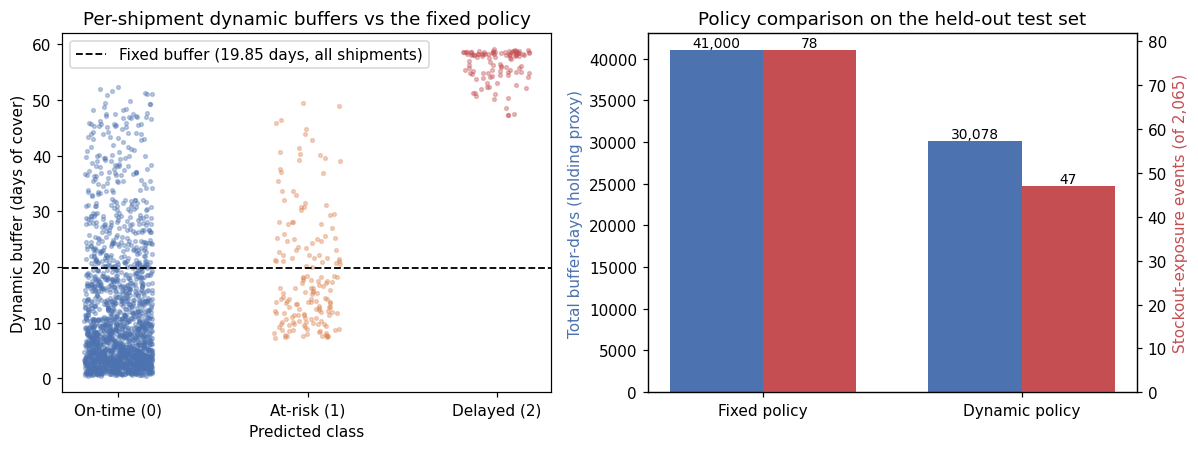

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
palette = {0: "#4C72B0", 1: "#DD8452", 2: "#C44E52"}
for c in CLASSES:
    sub = ss_frame[ss_frame["pred_class"] == c]
    axes[0].scatter(np.full(len(sub), c)
                    + np.random.default_rng(42).uniform(-0.18, 0.18,
                                                        len(sub)),
                    sub["buffer_dynamic_days"], s=6, alpha=0.35,
                    color=palette[c])
axes[0].axhline(ss_summary["fixed_buffer_days_per_shipment"],
                color="black", ls="--", lw=1.2,
                label=f"Fixed buffer "
                      f"({ss_summary['fixed_buffer_days_per_shipment']} "
                      "days, all shipments)")
axes[0].set_xticks(CLASSES); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylabel("Dynamic buffer (days of cover)")
axes[0].set_xlabel("Predicted class")
axes[0].set_title("Per-shipment dynamic buffers vs the fixed policy")
axes[0].legend()

labels = ["Fixed policy", "Dynamic policy"]
buffer_totals = [ss_summary["total_buffer_days_fixed"],
                 ss_summary["total_buffer_days_dynamic"]]
stockouts = [ss_summary["stockouts_fixed"],
             ss_summary["stockouts_dynamic"]]
x = np.arange(2)
ax2 = axes[1]
b1 = ax2.bar(x - 0.18, buffer_totals, width=0.36, color="#4C72B0",
             label="Total buffer-days held")
ax2.set_ylabel("Total buffer-days (holding proxy)", color="#4C72B0")
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax3 = ax2.twinx()
b2 = ax3.bar(x + 0.18, stockouts, width=0.36, color="#C44E52",
             label="Stockout-exposure events")
ax3.set_ylabel("Stockout-exposure events (of 2,065)", color="#C44E52")
ax2.set_title("Policy comparison on the held-out test set")
for b in b1:
    ax2.annotate(f"{b.get_height():,.0f}", (b.get_x()+b.get_width()/2,
                 b.get_height()), ha="center", va="bottom", fontsize=9)
for b in b2:
    ax3.annotate(f"{b.get_height():,.0f}", (b.get_x()+b.get_width()/2,
                 b.get_height()), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/safety_stock_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Summary

- The final champion's held-out performance, per-class behaviour, and generalization gap are recorded in `outputs/tables/test_metrics_final.csv` and `test_classification_report_final.csv`.
- RQ1 is closed by the attribute-level SHAP ranking (`shap_grouped_importance.csv`).
- The cost-sensitive decision rule, selected without touching the test set, trades On-time precision for a substantial At-risk recall gain — quantified in `decision_rule_comparison_test.csv` with sensitivity to the assumed cost ratio.
- RQ3 is closed by the safety-stock simulation (`safety_stock_summary.csv`): the dynamic policy's buffer-days and stockout-exposure totals against the fixed policy, with the Milestone 1 directional criterion checked explicitly.

The final report interprets these results, compares them with prior work, and states the answers to all three research questions.